In [1]:
!pip install opencv-python


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten,Conv2D,MaxPool2D
import cv2


In [3]:
!pip install pygame tensorflow

In [ ]:
##getting the data and preprocessing

In [5]:
(X_train, y_train), (X_test, y_test)=mnist.load_data()
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [6]:
def plt_input_img(i):
  plt.imshow(X_train[i],cmap='binary')
  plt.xlabel(y_train[i])
  plt.show()

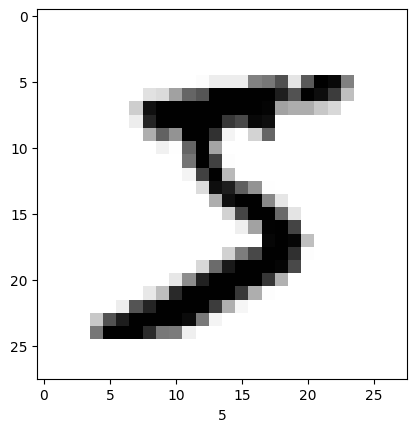

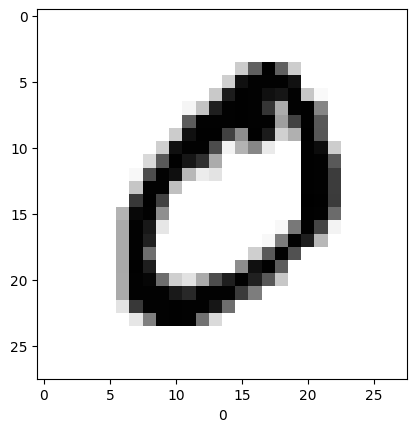

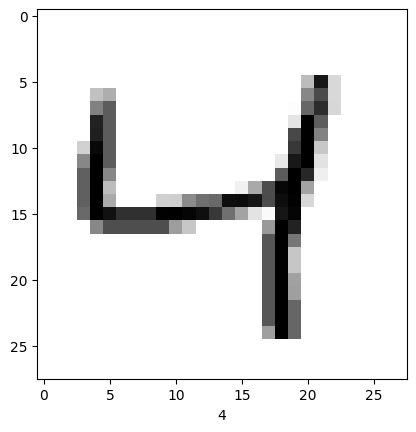

In [7]:
for i in range(3):
  plt_input_img(i)

In [ ]:
##preprocess and clean the data for missing and incorrect representation



In [8]:

#The original data set contains 60000 images of size 28*28 pixels. Each pixel is represented by an integer value between 0 and 255. After this transformation,
# each pixel is represented by a floating-point number between 0 and 1.
X_train=X_train.astype(np.float32)/255
X_test=X_test.astype(np.float32)/255

#expanding from28,28 to 28,28,1 becqase CNN's format of taking images
X_train=np.expand_dims(X_train,-1)
X_test=np.expand_dims(X_test,-1)


In [9]:
#doing one hot encoding for all classes
y_train=keras.utils.to_categorical(y_train)

In [10]:
y_test=keras.utils.to_categorical(y_test)

In [11]:
y_train


array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [54]:
model_complex = Sequential()

model_complex.add(Conv2D(64, (3, 3), input_shape=(28, 28, 1), activation='relu'))
model_complex.add(MaxPool2D(2, 2))

model_complex.add(Conv2D(128, (3, 3), activation='relu'))
model_complex.add(MaxPool2D(2, 2))

model_complex.add(Conv2D(256, (3, 3), activation='relu'))
model_complex.add(MaxPool2D(2, 2))


model_complex.add(Flatten())
model_complex.add(Dropout(0.5)) # Increased dropout rate
model_complex.add(Dense(128, activation='relu')) # Added a dense layer
model_complex.add(Dropout(0.5)) # Added dropout after the new dense layer
model_complex.add(Dense(128, activation='relu')) # Added a dense layer
model_complex.add(Dropout(0.5)) # Added dropout after the new dense layer
model_complex.add(Dense(10, activation='linear')) # Output layer

In [55]:
model.summary(
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,480 (408.13 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,654 (272.09 KB)

In [56]:
model.compile(optimizer='adam',loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [57]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping: Stop training if validation accuracy doesn't improve
es = EarlyStopping(monitor='val_accuracy', mode='max', min_delta=0.0001, patience=4, verbose=1)

# ModelCheckpoint: Save the best model based on validation accuracy
mc = ModelCheckpoint('best_model_new.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

# Pass the callbacks to the model.fit function
callbacks = [es, mc]

In [58]:
his = model.fit(X_train,y_train,epochs=6,validation_split=0.2,callbacks=callbacks)

Epoch 1/6
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9976 - loss: 0.0065
Epoch 1: val_accuracy improved from -inf to 0.99183, saving model to best_model_new.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9976 - loss: 0.0065 - val_accuracy: 0.9918 - val_loss: 0.0480
Epoch 2/6
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9978 - loss: 0.0075
Epoch 2: val_accuracy improved from 0.99183 to 0.99208, saving model to best_model_new.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9978 - loss: 0.0075 - val_accuracy: 0.9921 - val_loss: 0.0450
Epoch 3/6
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9976 - loss: 0.0065
Epoch 3: val_accuracy did not improve from 0.99208
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9976 - loss: 0.0065 - val_accuracy: 0.9916 - val_loss: 0.0480
Epoch 4/6
1482/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9976 - loss: 0.0082
Epoch 4: val_accuracy did not improve from 0.99208
1500/1500 

In [35]:
model_S.save('/content/best_model_99.78_val_99.23.keras')

In [64]:
from IPython.display import display, HTML, clear_output
from google.colab import output
from google.colab.output import eval_js
from ipywidgets import widgets
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import base64
import io
import cv2

# Load the model
model = load_model('/content/best_model_99.78_val_99.23.keras')

# Labels dictionary
LABELS = {0:"Zero", 1:"One", 2:"Two", 3:"Three", 4:"Four", 5:"Five", 6:"Six", 7:"Seven", 8:"Eight", 9:"Nine"}

# HTML and JavaScript for the drawing canvas
html_canvas = """
<canvas id="canvas" width="280" height="280" style="border:1px solid #b9bfc9;margin-top:25px;margin-left:25px;"></canvas>
<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.fillStyle = 'black';
ctx.fillRect(0, 0, canvas.width, canvas.height);
var isDrawing = false;
var lastX = 0;
var lastY = 0;
canvas.addEventListener('mousedown', (e) => {
    isDrawing = true;
    [lastX, lastY] = [e.clientX - canvas.offsetLeft, e.clientY - canvas.offsetTop];
});
canvas.addEventListener('mousemove', draw);
canvas.addEventListener('mouseup', () => isDrawing = false);
function draw(e) {
    if (!isDrawing) return;
    ctx.strokeStyle = 'white';
    ctx.lineWidth = 10;
    ctx.lineCap = 'round';
    ctx.beginPath();
    ctx.moveTo(lastX, lastY);
    ctx.lineTo(e.clientX - canvas.offsetLeft, e.clientY - canvas.offsetTop);
    ctx.stroke();
    [lastX, lastY] = [e.clientX - canvas.offsetLeft, e.clientY - canvas.offsetTop];
}
function clearCanvas() {
    ctx.fillStyle = 'black';
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}
function getImageData() {
    return canvas.toDataURL();
}
</script>
"""

# Display the canvas
display(HTML(html_canvas))

# Function to clear the canvas
def clear_canvas(b):
    eval_js('clearCanvas()')
    prediction_label.value = "Prediction: "

# Function to get image data from canvas
def get_image_data():
    data = eval_js('getImageData()')
    image_data = base64.b64decode(data.split(',')[1])
    image = plt.imread(io.BytesIO(image_data), format='png')
    return image[:,:,0]  # Return only one channel as it's grayscale

# Function to preprocess the image
def preprocess_image(image):
    # Convert to uint8
    image = (image * 255).astype(np.uint8)

    # Find bounding box of the digit
    points = cv2.findNonZero(image)
    x, y, w, h = cv2.boundingRect(points)

    # Crop the image to the bounding box
    cropped = image[y:y+h, x:x+w]

    # Resize to 20x20 while keeping aspect ratio
    resized = cv2.resize(cropped, (20, 20), interpolation=cv2.INTER_AREA)

    # Pad to 28x28
    padded = np.pad(resized, ((4,4), (4,4)), 'constant', constant_values=0)

    # Normalize
    normalized = padded.astype(np.float32) / 255.0

    # Reshape to (1, 28, 28, 1)
    reshaped = normalized.reshape(1, 28, 28, 1)

    return reshaped

# Function to predict the digit
def predict_digit():
    image = get_image_data()
    processed_image = preprocess_image(image)
    prediction = model.predict(processed_image)
    digit = np.argmax(prediction)
    return LABELS[digit], prediction[0][digit]

# Function to make a prediction
def make_prediction(b):
    digit, confidence = predict_digit()
    prediction_label.value = f"Prediction: {digit} (Confidence: {confidence:.2f})"

# Create buttons and labels
clear_button = widgets.Button(description="Clear")
clear_button.on_click(clear_canvas)

predict_button = widgets.Button(description="Predict")
predict_button.on_click(make_prediction)

prediction_label = widgets.Label(value="Prediction: ")

# Display buttons and prediction label
display(widgets.HBox([clear_button, predict_button]))
display(prediction_label)

Label(value='Prediction: ')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
